In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

data_dir = Path("/home/qmoreau/gogo_bursts/stats_new")
pc       = "12"
epoch    = "STIM"

tag    = f"PC_{pc}_{epoch}_RTage"
colors = {"LONG": "#5B8DB8", "SHORT": "#CA0020"}

In [2]:
anova = pd.read_csv(data_dir / f"{tag}_anova.csv")
anova = anova.rename(columns={"Chisq": "chisq", "Df": "df", "Pr(>Chisq)": "p"})
anova

,term,chisq,df,p
0,(Intercept),44493.667317,1,0.000000e+00
1,condition,1864.931018,1,0.000000e+00
2,age_c,7.142548,1,7.527614e-03
3,trial_idx_s,301.274109,1,1.738552e-67
4,condition:age_c,0.539187,1,4.627700e-01


In [3]:
def fmt_p(p):
    return "p < .001" if p < .001 else f"p = {p:.3f}".replace("0.", ".")

for _, r in anova.iterrows():
    print(f"{r['term']}: chi2({r['df']:.0f}) = {r['chisq']:.2f}, {fmt_p(r['p'])}")

(Intercept): chi2(1) = 44493.67, p < .001
condition: chi2(1) = 1864.93, p < .001
age_c: chi2(1) = 7.14, p = .008
trial_idx_s: chi2(1) = 301.27, p < .001
condition:age_c: chi2(1) = 0.54, p = .463


In [4]:
trends   = pd.read_csv(data_dir / f"{tag}_emtrends.csv")
contrast = pd.read_csv(data_dir / f"{tag}_emtrends_contrasts.csv")

for _, r in trends.iterrows():
    print(f"{r['condition']}: b = {r['age_c.trend']:+.3f} per SD of age "
          f"[{r['asymp.LCL']:+.3f}, {r['asymp.UCL']:+.3f}], "
          f"z = {r['z.ratio']:.2f}, {fmt_p(r['p.value'])}  "
          f"({r['pct_per_year']:+.1f}% RT per year)")

print()
for _, r in contrast.iterrows():
    print(f"{r['contrast']}: b = {r['estimate']:+.3f}, "
          f"z = {r['z.ratio']:.2f}, {fmt_p(r['p.value'])}")

LONG: b = -0.075 per SD of age [-0.131, -0.020], z = -2.67, p = .008  (-2.8% RT per year)
SHORT: b = -0.078 per SD of age [-0.134, -0.023], z = -2.76, p = .006  (-2.9% RT per year)

LONG - SHORT: b = +0.003, z = 0.73, p = .463


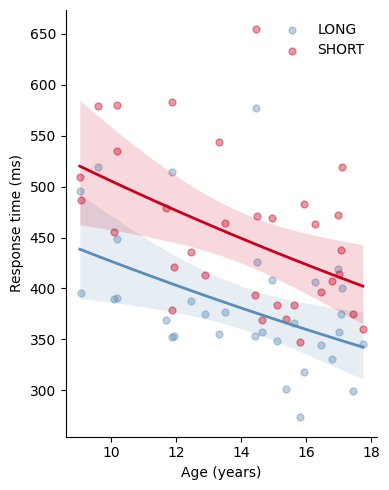

In [6]:
pred = pd.read_csv(data_dir / f"{tag}_predictions.csv")
obs  = pd.read_csv(data_dir / f"{tag}_observed.csv")

fig, ax = plt.subplots(figsize=(4, 5))

for cond, col in colors.items():
    o = obs[obs.condition == cond]
    p = pred[pred.condition == cond].sort_values("age")

    ax.scatter(o.age, o.rt_ms, color=col, alpha=.4, s=25, label=cond)
    ax.fill_between(p.age, p["asymp.LCL"], p["asymp.UCL"],
                    color=col, alpha=.15, linewidth=0)
    ax.plot(p.age, p.response, color=col, linewidth=2)

ax.set_xlabel("Age (years)")
ax.set_ylabel("Response time (ms)")
ax.legend(frameon=False, loc="upper right")
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
fig.savefig(data_dir / f"{tag}_trends.png", dpi=300)